In [1]:
%pip install -U langchain langchain-openai langgraph-checkpoint-sqlite
!apt-get install -y graphviz graphviz-dev
!pip install pygraphviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.7/84.7 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 484.9/484.9 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.6/151.6 kB 6.9 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.2.1
    Uninstalling langchain-core-1.2.1:
      Successfully uninstalled langchain-core-1.2.1
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Note, selecting 'libgraphviz-dev' instead of 'graphviz-dev'
graphviz is already the newest version (2.42.2-6ubuntu0.1).
The following additional packages will be installed:
  libatk1.0-0 libatk1.0-data libgail-common libgail18 libgtk2.0-0
  libgtk2.0-bin libgtk2.0-common libgvc6-plugins-gtk librsvg2-common
  libxcomposite1 libxdot4
Suggested packages:
  gvfs
The following NEW packages will be installed:
  libatk1.0-0 libatk1.0-data libgail-common libgail18 libgraphviz-dev
  l

In [4]:
from google.colab import userdata
API_KEY = userdata.get('SILICONFLOW_API_KEY')
from langchain.chat_models import init_chat_model
from IPython.display import Image, display
# === LLM 初始化 ===
model = init_chat_model(
    "Qwen/Qwen3-8B",
    model_provider="openai",
    base_url="https://api.siliconflow.cn/v1",
    api_key= API_KEY,
    temperature=0.0
)

def display_graph(app):
  # 使用 Graphviz 渲染（Colab 最稳定的方案）
  try:
      display(Image(app.get_graph(xray=True).draw_png()))
  except Exception as e:
      print(f"Graphviz 渲染失败: {e}")
      print("\n使用 Mermaid 文本方式显示:")
      print(app.get_graph(xray=True).draw_mermaid())

## 1. 为什么需要多智能体系统？

### 1.1 单一 Agent 的局限性

**问题：**

- ❌ 一个 Agent 承担所有任务，职责不清
- ❌ Prompt 过于复杂，难以维护
- ❌ 无法实现专业化分工
- ❌ 难以复用和组合

**示例：旅行规划**

```python
# ❌ 单一 Agent 需要处理所有事情
single_agent_prompt = """
你是一个旅行规划助手，需要：
1. 搜索并推荐航班
2. 搜索并推荐酒店
3. 推荐当地活动
4. 估算总预算
5. 生成行程表
6. 提供天气信息
7. 提供签证信息
... (太多了！)
"""
```

### 1.2 多智能体的优势

**解决方案：专业化分工**

- ✅ 每个 Agent 专注一个领域
- ✅ Prompt 简单清晰
- ✅ 独立开发和测试
- ✅ 可复用和组合

**示例：多 Agent 系统**

```
旅行规划系统
├── 航班专家 Agent（专注航班搜索和推荐）
├── 酒店专家 Agent（专注酒店搜索和推荐）
├── 活动专家 Agent（专注当地活动推荐）
└── 协调器 Agent（整合信息，生成最终方案）
```

---

## 2. Subgraphs：图中的图

### 2.1 什么是 Subgraph？

**Subgraph（子图）** 就是嵌套在主图中的一个完整的图：

- 子图本身是一个独立的 Graph
- 子图可以被当作一个节点在主图中使用
- 子图有自己的 State、Nodes、Edges

**概念对比：**

```
普通节点 = 一个函数
Subgraph = 一个完整的图（包含多个节点、边）
```

### 2.2 为什么使用 Subgraph？

**优势：**

- ✅ **模块化**：复杂逻辑封装成独立的子图
- ✅ **可复用**：同一个子图可以在多处使用
- ✅ **清晰**：主图保持简洁，细节在子图中
- ✅ **独立测试**：每个子图可以单独测试

### 2.3 基本示例

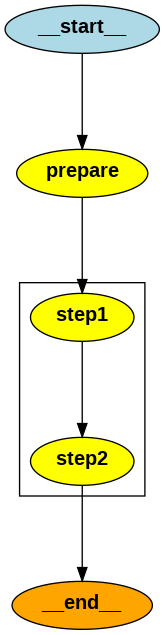

输入: 5
子图处理: 5 * 2 + 10 = 20


In [6]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

# === 子图 State ===
class SubGraphState(TypedDict):
    input_value: int
    result: int

# === 子图节点 ===
def sub_step1(state: SubGraphState) -> dict:
    """子图步骤 1"""
    return {"result": state["input_value"] * 2}

def sub_step2(state: SubGraphState) -> dict:
    """子图步骤 2"""
    return {"result": state["result"] + 10}

# === 创建子图 ===
sub_graph = StateGraph(SubGraphState)
sub_graph.add_node("step1", sub_step1)
sub_graph.add_node("step2", sub_step2)
sub_graph.add_edge(START, "step1")
sub_graph.add_edge("step1", "step2")
sub_graph.add_edge("step2", END)

# 编译子图
sub_graph_compiled = sub_graph.compile()

# === 主图 State ===
class MainState(TypedDict):
    number: int
    final_result: int

# === 主图节点（使用子图）===
def prepare_input(state: MainState) -> dict:
    """准备输入"""
    return {"number": state["number"]}

def use_subgraph(state: MainState) -> dict:
    """使用子图"""
    # 调用子图
    result = sub_graph_compiled.invoke({
        "input_value": state["number"],
        "result": 0
    })

    return {"final_result": result["result"]}

# === 创建主图 ===
main_graph = StateGraph(MainState)
main_graph.add_node("prepare", prepare_input)
main_graph.add_node("process", use_subgraph)

main_graph.add_edge(START, "prepare")
main_graph.add_edge("prepare", "process")
main_graph.add_edge("process", END)

main_app = main_graph.compile()
display_graph(main_app)
# === 测试 ===
result = main_app.invoke({"number": 5, "final_result": 0})
print(f"输入: 5")
print(f"子图处理: 5 * 2 + 10 = {result['final_result']}")  # 20

### 2.4 State 映射

**问题：主图和子图的 State 通常不同，如何传递数据？**

**解决方案：State 映射函数**

In [ ]:
from typing import TypedDict

# 主图 State
class ParentState(TypedDict):
    user_query: str
    search_results: list
    final_answer: str

# 子图 State
class SearchSubgraphState(TypedDict):
    query: str
    results: list

# === 映射函数 ===
def map_input_to_subgraph(parent_state: ParentState) -> SearchSubgraphState:
    """主图 → 子图：映射输入"""
    return {
        "query": parent_state["user_query"],
        "results": []
    }

def map_output_from_subgraph(
    parent_state: ParentState,
    subgraph_state: SearchSubgraphState
) -> dict:
    """子图 → 主图：映射输出"""
    return {
        "search_results": subgraph_state["results"]
    }

# === 使用映射的节点 ===
def search_node(state: ParentState) -> dict:
    """使用子图进行搜索"""
    # 映射输入
    sub_input = map_input_to_subgraph(state)

    # 调用子图
    sub_result = search_subgraph.invoke(sub_input)

    # 映射输出
    return map_output_from_subgraph(state, sub_result)

## 3. 多智能体协作模式

### 3.1 模式 1：顺序协作（Sequential）

**特点：** Agent 按顺序执行，每个 Agent 的输出是下一个 Agent 的输入。

```
Agent A → Agent B → Agent C → 结果
```

**示例：文档处理流水线**

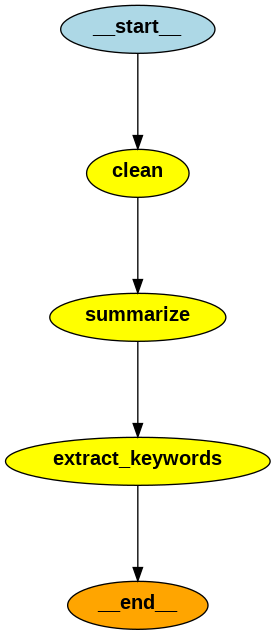

{'raw_text': '这是   一段    需要处理的   文本...', 'cleaned_text': '这是 一段 需要处理的 文本...', 'summary': '摘要：这是 一段 需要处理的 文本......', 'keywords': ['关键词1', '关键词2', '关键词3']}


In [7]:
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages

class DocumentState(TypedDict):
    raw_text: str
    cleaned_text: str
    summary: str
    keywords: list

# Agent 1: 清理文本
def cleaning_agent(state: DocumentState) -> dict:
    """清理文本 Agent"""
    raw = state["raw_text"]
    # 移除多余空格、特殊字符等
    cleaned = " ".join(raw.split())
    return {"cleaned_text": cleaned}

# Agent 2: 生成摘要
def summary_agent(state: DocumentState) -> dict:
    """摘要 Agent"""
    text = state["cleaned_text"]
    # 使用 LLM 生成摘要
    summary = f"摘要：{text[:100]}..."
    return {"summary": summary}

# Agent 3: 提取关键词
def keyword_agent(state: DocumentState) -> dict:
    """关键词提取 Agent"""
    text = state["cleaned_text"]
    # 使用 LLM 或 NLP 工具提取关键词
    keywords = ["关键词1", "关键词2", "关键词3"]
    return {"keywords": keywords}

# 构建顺序流水线
sequential_graph = StateGraph(DocumentState)
sequential_graph.add_node("clean", cleaning_agent)
sequential_graph.add_node("summarize", summary_agent)
sequential_graph.add_node("extract_keywords", keyword_agent)

sequential_graph.add_edge(START, "clean")
sequential_graph.add_edge("clean", "summarize")
sequential_graph.add_edge("summarize", "extract_keywords")
sequential_graph.add_edge("extract_keywords", END)

sequential_app = sequential_graph.compile()
display_graph(sequential_app)

# 测试
result = sequential_app.invoke({
    "raw_text": "这是   一段    需要处理的   文本...",
    "cleaned_text": "",
    "summary": "",
    "keywords": []
})
print(result)

### 3.2 模式 2：并行协作（Parallel）

**特点：** 多个 Agent 同时执行，互不依赖。

```
       ┌─ Agent A ─┐
Input   ─┼─ Agent B ─┼─ 汇总 ─ 结果
       └─ Agent C ─┘
```

**示例：多角度分析**

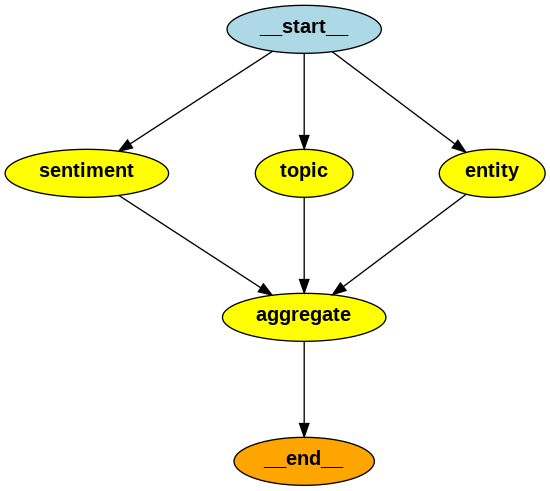


汇总所有分析结果：
  - entity: 实体：公司名、人名
  - sentiment: 情感：正面
  - topic: 主题：技术


In [8]:
from operator import add

class AnalysisState(TypedDict):
    content: str
    sentiment_analysis: str
    topic_analysis: str
    entity_analysis: str
    all_analyses: Annotated[list, add]

# 并行的 Agent
def sentiment_agent(state: AnalysisState) -> dict:
    """情感分析 Agent"""
    result = "情感：正面"
    return {
        "sentiment_analysis": result,
        "all_analyses": [{"type": "sentiment", "result": result}]
    }

def topic_agent(state: AnalysisState) -> dict:
    """主题分析 Agent"""
    result = "主题：技术"
    return {
        "topic_analysis": result,
        "all_analyses": [{"type": "topic", "result": result}]
    }

def entity_agent(state: AnalysisState) -> dict:
    """实体提取 Agent"""
    result = "实体：公司名、人名"
    return {
        "entity_analysis": result,
        "all_analyses": [{"type": "entity", "result": result}]
    }

def aggregate_results(state: AnalysisState) -> dict:
    """汇总结果"""
    print("\n汇总所有分析结果：")
    for analysis in state["all_analyses"]:
        print(f"  - {analysis['type']}: {analysis['result']}")
    return {}

# 构建并行图
parallel_graph = StateGraph(AnalysisState)

# 添加并行节点
parallel_graph.add_node("sentiment", sentiment_agent)
parallel_graph.add_node("topic", topic_agent)
parallel_graph.add_node("entity", entity_agent)
parallel_graph.add_node("aggregate", aggregate_results)

# 从 START 到所有分析节点（并行）
parallel_graph.add_edge(START, "sentiment")
parallel_graph.add_edge(START, "topic")
parallel_graph.add_edge(START, "entity")

# 所有分析完成后汇总
parallel_graph.add_edge("sentiment", "aggregate")
parallel_graph.add_edge("topic", "aggregate")
parallel_graph.add_edge("entity", "aggregate")

parallel_graph.add_edge("aggregate", END)

parallel_app = parallel_graph.compile()

display_graph(parallel_app)

# 测试
result = parallel_app.invoke({
    "content": "这是要分析的内容...",
    "all_analyses": []
})

### 3.3 模式 3：主控-专家模式（Supervisor-Expert）

**特点：** 主控 Agent 分配任务给专家 Agent，并整合结果。

```
          ┌─→ 专家 A ─┐
主控 Agent ─┼─→ 专家 B ─┼─→ 主控 Agent（整合）─→ 结果
          └─→ 专家 C ─┘
```

**示例：客服系统

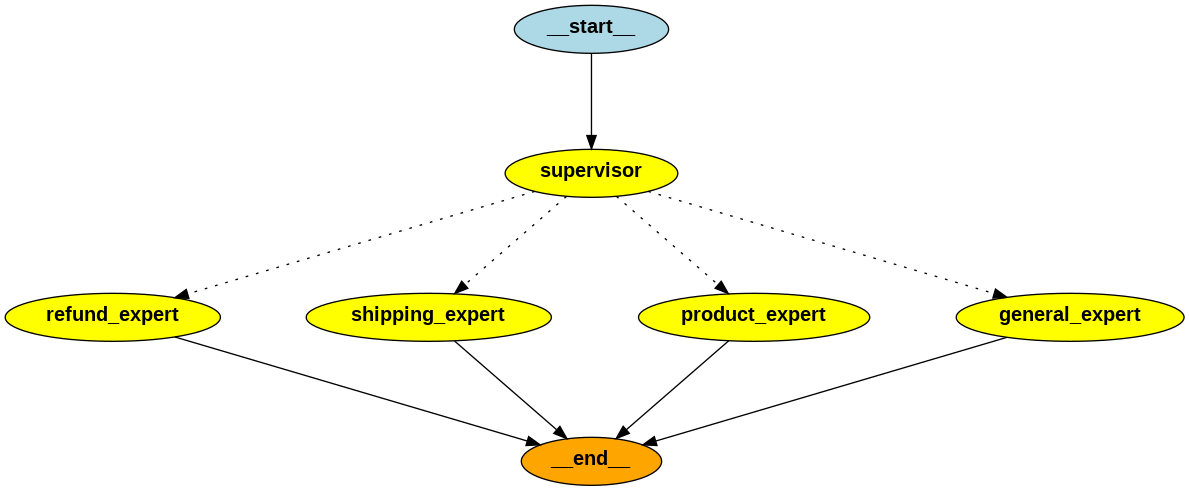

查询: 我要退款
回复: 退款专家：您可以在订单页面申请退款，1-3个工作日到账。

查询: 物流在哪里
回复: 物流专家：您可以在订单详情查看物流信息。

查询: 产品怎么用
回复: 产品专家：请详细描述您的产品问题，我会帮您解答。



In [17]:
from typing import Literal

class CustomerServiceState(TypedDict):
    user_query: str
    intent: str
    response: str
    expert_responses: Annotated[list, add]

# 主控 Agent：意图分类
def supervisor_classify(state: CustomerServiceState) -> dict:
    """主控：分类用户意图"""
    query = state["user_query"]

    # 简化：关键词匹配
    if "退款" in query or "退货" in query:
        intent = "refund"
    elif "物流" in query or "配送" in query:
        intent = "shipping"
    elif "产品" in query or "功能" in query:
        intent = "product"
    else:
        intent = "general"

    return {"intent": intent}

# 路由到专家
def route_to_expert(state: CustomerServiceState) -> Literal["refund_expert", "shipping_expert", "product_expert", "general_expert"]:
    """路由到相应的专家"""
    intent = state["intent"]
    return f"{intent}_expert"

# 专家 Agent
def refund_expert(state: CustomerServiceState) -> dict:
    """退款专家"""
    response = "退款专家：您可以在订单页面申请退款，1-3个工作日到账。"
    return {
        "expert_responses": [response],
        "response": response
    }

def shipping_expert(state: CustomerServiceState) -> dict:
    """物流专家"""
    response = "物流专家：您可以在订单详情查看物流信息。"
    return {
        "expert_responses": [response],
        "response": response
    }

def product_expert(state: CustomerServiceState) -> dict:
    """产品专家"""
    response = "产品专家：请详细描述您的产品问题，我会帮您解答。"
    return {
        "expert_responses": [response],
        "response": response
    }

def general_expert(state: CustomerServiceState) -> dict:
    """通用专家"""
    response = "客服：请问有什么可以帮助您的？"
    return {
        "expert_responses": [response],
        "response": response
    }

# 构建主控-专家图
supervisor_graph = StateGraph(CustomerServiceState)

# 主控
supervisor_graph.add_node("supervisor", supervisor_classify)

# 专家
supervisor_graph.add_node("refund_expert", refund_expert)
supervisor_graph.add_node("shipping_expert", shipping_expert)
supervisor_graph.add_node("product_expert", product_expert)
supervisor_graph.add_node("general_expert", general_expert)

# 流程
supervisor_graph.add_edge(START, "supervisor")
supervisor_graph.add_conditional_edges(
    "supervisor",
    route_to_expert,
    {
        "refund_expert": "refund_expert",
        "shipping_expert": "shipping_expert",
        "product_expert": "product_expert",
        "general_expert": "general_expert"
    }
)


# 所有专家流向 END
for expert in ["refund_expert", "shipping_expert", "product_expert", "general_expert"]:
    supervisor_graph.add_edge(expert, END)
    # supervisor_graph.add_edge(expert, "supervisor")

supervisor_app = supervisor_graph.compile()

display_graph(supervisor_app)

# 测试
queries = ["我要退款", "物流在哪里", "产品怎么用"]
for query in queries:
    result = supervisor_app.invoke({
        "user_query": query,
        "intent": "",
        "response": "",
        "expert_responses": []
    })
    print(f"查询: {query}")
    print(f"回复: {result['response']}\n")

### 3.4 模式 4：协商模式（Consensus）

**特点：** 多个 Agent 投票或协商，达成一致决策。

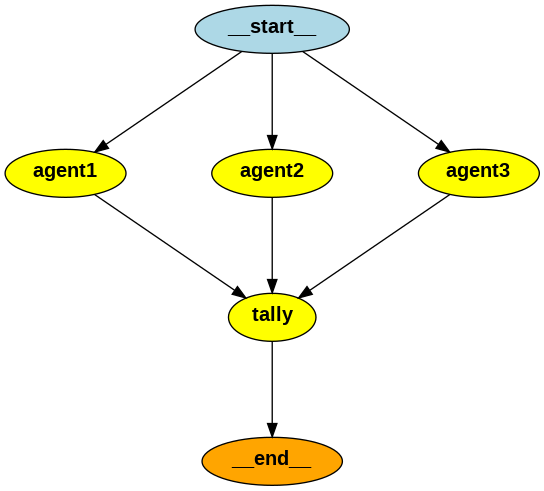


投票结果：3/3 同意
决策：提案通过



In [10]:
class VotingState(TypedDict):
    proposal: str
    votes: Annotated[list, add]
    decision: str

# 投票 Agent
def agent_1_vote(state: VotingState) -> dict:
    """Agent 1 投票"""
    vote = "同意" if "优化" in state["proposal"] else "反对"
    return {"votes": [{"agent": "Agent1", "vote": vote}]}

def agent_2_vote(state: VotingState) -> dict:
    """Agent 2 投票"""
    vote = "同意" if "成本" in state["proposal"] else "反对"
    return {"votes": [{"agent": "Agent2", "vote": vote}]}

def agent_3_vote(state: VotingState) -> dict:
    """Agent 3 投票"""
    vote = "同意"  # 总是同意
    return {"votes": [{"agent": "Agent3", "vote": vote}]}

def tally_votes(state: VotingState) -> dict:
    """统计投票"""
    votes = state["votes"]
    approve_count = sum(1 for v in votes if v["vote"] == "同意")
    total = len(votes)

    if approve_count > total / 2:
        decision = "提案通过"
    else:
        decision = "提案被拒绝"

    print(f"\n投票结果：{approve_count}/{total} 同意")
    print(f"决策：{decision}\n")

    return {"decision": decision}

# 构建投票图
voting_graph = StateGraph(VotingState)
voting_graph.add_node("agent1", agent_1_vote)
voting_graph.add_node("agent2", agent_2_vote)
voting_graph.add_node("agent3", agent_3_vote)
voting_graph.add_node("tally", tally_votes)

# 并行投票
voting_graph.add_edge(START, "agent1")
voting_graph.add_edge(START, "agent2")
voting_graph.add_edge(START, "agent3")

# 统计
voting_graph.add_edge("agent1", "tally")
voting_graph.add_edge("agent2", "tally")
voting_graph.add_edge("agent3", "tally")

voting_graph.add_edge("tally", END)

voting_app = voting_graph.compile()
display_graph(voting_app)

# 测试
result = voting_app.invoke({
    "proposal": "优化成本结构",
    "votes": [],
    "decision": ""
})

## 4. 综合实战：旅行规划助手

现在让我们构建一个完整的多智能体旅行规划系统：

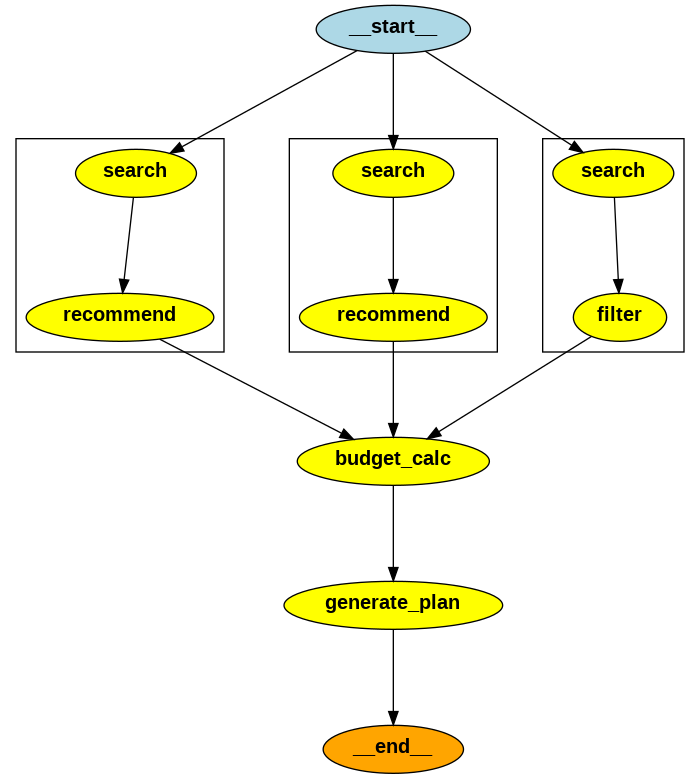

In [19]:
"""
综合实战：旅行规划助手

架构：
- 主控 Agent：协调整个规划流程
- 航班专家：搜索和推荐航班
- 酒店专家：搜索和推荐酒店
- 活动专家：推荐当地活动
- 预算专家：估算总成本

使用 Subgraphs 实现每个专家
"""

from typing import TypedDict, Annotated, Literal
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import HumanMessage, SystemMessage
from operator import add
import json

# ============================================
# State 定义
# ============================================

# === 主 State ===
class TravelPlanState(TypedDict):
    # 用户输入
    destination: str
    start_date: str
    end_date: str
    num_travelers: int
    budget: float

    # 专家结果
    flight_recommendations: list
    hotel_recommendations: list
    activity_recommendations: list
    budget_breakdown: dict

    # 最终方案
    final_plan: str
    total_cost: float

# === 航班子图 State ===
class FlightSearchState(TypedDict):
    destination: str
    start_date: str
    end_date: str
    num_travelers: int
    search_results: list
    recommendations: list

# === 酒店子图 State ===
class HotelSearchState(TypedDict):
    destination: str
    start_date: str
    end_date: str
    num_travelers: int
    search_results: list
    recommendations: list

# === 活动子图 State ===
class ActivitySearchState(TypedDict):
    destination: str
    start_date: str
    end_date: str
    num_travelers: int
    activities: list

# ============================================
# 工具和辅助函数
# ============================================


def search_flights_api(destination: str, date: str, travelers: int) -> list:
    """模拟航班搜索 API"""
    # 实际应用中调用真实的航班 API
    return [
        {
            "airline": "航空公司 A",
            "departure": "08:00",
            "arrival": "12:00",
            "price": 1200,
            "duration": "4h"
        },
        {
            "airline": "航空公司 B",
            "departure": "14:00",
            "arrival": "18:00",
            "price": 950,
            "duration": "4h"
        }
    ]

def search_hotels_api(destination: str, checkin: str, checkout: str) -> list:
    """模拟酒店搜索 API"""
    return [
        {
            "name": "豪华酒店",
            "rating": 5,
            "price_per_night": 800,
            "amenities": ["游泳池", "健身房", "早餐"]
        },
        {
            "name": "经济酒店",
            "rating": 3,
            "price_per_night": 300,
            "amenities": ["WiFi", "早餐"]
        }
    ]

def search_activities_api(destination: str) -> list:
    """模拟活动搜索 API"""
    return [
        {"name": "城市观光", "duration": "4h", "price": 200},
        {"name": "博物馆参观", "duration": "3h", "price": 150},
        {"name": "美食tour", "duration": "3h", "price": 300}
    ]

# ============================================
# 子图 1：航班专家
# ============================================

def flight_search_node(state: FlightSearchState) -> dict:
    """搜索航班"""
    print("✈️  搜索航班...")

    results = search_flights_api(
        state["destination"],
        state["start_date"],
        state["num_travelers"]
    )

    return {"search_results": results}

def flight_recommend_node(state: FlightSearchState) -> dict:
    """AI 推荐航班"""
    print("🤖 AI 分析航班...")

    results = state["search_results"]

    # 使用 LLM 分析
    prompt = f"""
基于以下航班信息，推荐最佳选项（考虑价格、时间、便利性）：

{json.dumps(results, ensure_ascii=False, indent=2)}

返回推荐理由。
"""

    response = model.invoke([HumanMessage(content=prompt)])

    recommendations = [
        {
            "flight": results[0],
            "reason": response.content
        }
    ]

    return {"recommendations": recommendations}

# 构建航班子图
flight_subgraph = StateGraph(FlightSearchState)
flight_subgraph.add_node("search", flight_search_node)
flight_subgraph.add_node("recommend", flight_recommend_node)
flight_subgraph.add_edge(START, "search")
flight_subgraph.add_edge("search", "recommend")
flight_subgraph.add_edge("recommend", END)

flight_agent = flight_subgraph.compile()

# ============================================
# 子图 2：酒店专家
# ============================================

def hotel_search_node(state: HotelSearchState) -> dict:
    """搜索酒店"""
    print("🏨 搜索酒店...")

    results = search_hotels_api(
        state["destination"],
        state["start_date"],
        state["end_date"]
    )

    return {"search_results": results}

def hotel_recommend_node(state: HotelSearchState) -> dict:
    """AI 推荐酒店"""
    print("🤖 AI 分析酒店...")

    results = state["search_results"]

    # 使用 LLM 分析
    prompt = f"""
基于以下酒店信息，推荐最佳选项：

{json.dumps(results, ensure_ascii=False, indent=2)}

返回推荐理由。
"""

    response = model.invoke([HumanMessage(content=prompt)])

    recommendations = [
        {
            "hotel": results[1],  # 选择经济型
            "reason": response.content
        }
    ]

    return {"recommendations": recommendations}

# 构建酒店子图
hotel_subgraph = StateGraph(HotelSearchState)
hotel_subgraph.add_node("search", hotel_search_node)
hotel_subgraph.add_node("recommend", hotel_recommend_node)
hotel_subgraph.add_edge(START, "search")
hotel_subgraph.add_edge("search", "recommend")
hotel_subgraph.add_edge("recommend", END)

hotel_agent = hotel_subgraph.compile()

# ============================================
# 子图 3：活动专家
# ============================================

def activity_search_node(state: ActivitySearchState) -> dict:
    """搜索活动"""
    print("🎯 搜索活动...")

    activities = search_activities_api(state["destination"])

    return {"activities": activities}

def activity_filter_node(state: ActivitySearchState) -> dict:
    """筛选合适的活动"""
    print("🤖 AI 筛选活动...")

    activities = state["activities"]

    # 简化：选择前2个
    selected = activities[:2]

    return {"activities": selected}

# 构建活动子图
activity_subgraph = StateGraph(ActivitySearchState)
activity_subgraph.add_node("search", activity_search_node)
activity_subgraph.add_node("filter", activity_filter_node)
activity_subgraph.add_edge(START, "search")
activity_subgraph.add_edge("search", "filter")
activity_subgraph.add_edge("filter", END)

activity_agent = activity_subgraph.compile()

# ============================================
# 主图：协调所有专家
# ============================================

def call_flight_expert(state: TravelPlanState) -> dict:
    """调用航班专家"""
    result = flight_agent.invoke({
        "destination": state["destination"],
        "start_date": state["start_date"],
        "end_date": state["end_date"],
        "num_travelers": state["num_travelers"],
        "search_results": [],
        "recommendations": []
    })

    return {"flight_recommendations": result["recommendations"]}

def call_hotel_expert(state: TravelPlanState) -> dict:
    """调用酒店专家"""
    result = hotel_agent.invoke({
        "destination": state["destination"],
        "start_date": state["start_date"],
        "end_date": state["end_date"],
        "num_travelers": state["num_travelers"],
        "search_results": [],
        "recommendations": []
    })

    return {"hotel_recommendations": result["recommendations"]}

def call_activity_expert(state: TravelPlanState) -> dict:
    """调用活动专家"""
    result = activity_agent.invoke({
        "destination": state["destination"],
        "start_date": state["start_date"],
        "end_date": state["end_date"],
        "num_travelers": state["num_travelers"],
        "activities": []
    })

    return {"activity_recommendations": result["activities"]}

def calculate_budget(state: TravelPlanState) -> dict:
    """计算总预算"""
    print("💰 计算预算...")

    # 航班费用
    flight = state["flight_recommendations"][0]["flight"]
    flight_cost = flight["price"] * state["num_travelers"]

    # 酒店费用
    hotel = state["hotel_recommendations"][0]["hotel"]
    from datetime import datetime
    start = datetime.strptime(state["start_date"], "%Y-%m-%d")
    end = datetime.strptime(state["end_date"], "%Y-%m-%d")
    nights = (end - start).days
    hotel_cost = hotel["price_per_night"] * nights

    # 活动费用
    activities = state["activity_recommendations"]
    activity_cost = sum(a["price"] for a in activities) * state["num_travelers"]

    total = flight_cost + hotel_cost + activity_cost

    breakdown = {
        "flight": flight_cost,
        "hotel": hotel_cost,
        "activities": activity_cost,
        "total": total
    }

    return {
        "budget_breakdown": breakdown,
        "total_cost": total
    }

def generate_final_plan(state: TravelPlanState) -> dict:
    """生成最终旅行计划"""
    print("📋 生成最终方案...")

    prompt = f"""
生成一份详细的旅行计划：

目的地：{state['destination']}
日期：{state['start_date']} 至 {state['end_date']}
人数：{state['num_travelers']}

航班：{json.dumps(state['flight_recommendations'][0], ensure_ascii=False)}
酒店：{json.dumps(state['hotel_recommendations'][0], ensure_ascii=False)}
活动：{json.dumps(state['activity_recommendations'], ensure_ascii=False)}

预算分解：{json.dumps(state['budget_breakdown'], ensure_ascii=False)}

请生成一份清晰、详细的旅行计划。
"""

    response = model.invoke([HumanMessage(content=prompt)])

    return {"final_plan": response.content}

# 构建主图
main_graph = StateGraph(TravelPlanState)

# 添加专家节点
main_graph.add_node("flight_expert", call_flight_expert)
main_graph.add_node("hotel_expert", call_hotel_expert)
main_graph.add_node("activity_expert", call_activity_expert)
main_graph.add_node("budget_calc", calculate_budget)
main_graph.add_node("generate_plan", generate_final_plan)

# 并行调用三个专家
main_graph.add_edge(START, "flight_expert")
main_graph.add_edge(START, "hotel_expert")
main_graph.add_edge(START, "activity_expert")

# 所有专家完成后计算预算
main_graph.add_edge("flight_expert", "budget_calc")
main_graph.add_edge("hotel_expert", "budget_calc")
main_graph.add_edge("activity_expert", "budget_calc")

# 生成最终方案
main_graph.add_edge("budget_calc", "generate_plan")
main_graph.add_edge("generate_plan", END)

# 编译
travel_planner_app = main_graph.compile()

display_graph(travel_planner_app)

In [ ]:
# ============================================
# 使用示例
# ============================================

def run_travel_planner_demo():
    """运行旅行规划演示"""
    print("\n" + "="*60)
    print("🌍 多智能体旅行规划助手")
    print("="*60 + "\n")

    # 用户需求
    request = {
        "destination": "日本东京",
        "start_date": "2024-06-01",
        "end_date": "2024-06-05",
        "num_travelers": 2,
        "budget": 20000,
        "flight_recommendations": [],
        "hotel_recommendations": [],
        "activity_recommendations": [],
        "budget_breakdown": {},
        "final_plan": "",
        "total_cost": 0
    }

    print(f"📝 规划需求：")
    print(f"  目的地：{request['destination']}")
    print(f"  日期：{request['start_date']} ~ {request['end_date']}")
    print(f"  人数：{request['num_travelers']}")
    print(f"  预算：¥{request['budget']}\n")

    print("开始规划...\n")

    # 执行
    result = travel_planner_app.invoke(request)

    # 显示结果
    print("\n" + "="*60)
    print("📊 规划结果")
    print("="*60 + "\n")

    print("✈️  航班推荐：")
    flight = result["flight_recommendations"][0]["flight"]
    print(f"  {flight['airline']} - {flight['departure']}~{flight['arrival']}")
    print(f"  价格：¥{flight['price']} x {request['num_travelers']} = ¥{flight['price'] * request['num_travelers']}\n")

    print("🏨 酒店推荐：")
    hotel = result["hotel_recommendations"][0]["hotel"]
    print(f"  {hotel['name']} ({hotel['rating']}星)")
    print(f"  价格：¥{hotel['price_per_night']}/晚\n")

    print("🎯 活动推荐：")
    for activity in result["activity_recommendations"]:
        print(f"  - {activity['name']} ({activity['duration']}) - ¥{activity['price']}")
    print()

    print("💰 预算分解：")
    breakdown = result["budget_breakdown"]
    print(f"  航班：¥{breakdown['flight']}")
    print(f"  酒店：¥{breakdown['hotel']}")
    print(f"  活动：¥{breakdown['activities']}")
    print(f"  总计：¥{breakdown['total']}\n")

    if breakdown["total"] <= request["budget"]:
        print(f"✅ 在预算内（预算：¥{request['budget']}）\n")
    else:
        print(f"⚠️  超出预算 ¥{breakdown['total'] - request['budget']}\n")

    print("="*60)
    print("📋 完整方案")
    print("="*60)
    print(result["final_plan"])
    print("\n" + "="*60)
    print("✅ 规划完成！")
    print("="*60 + "\n")

if __name__ == "__main__":
    # 确保设置了 API key
    # import os
    # os.environ["OPENAI_API_KEY"] = "your-key"

    run_travel_planner_demo()